Notebook para processar os dados de veículo e tentar compreender a atribuição de veículos à linhas




In [2]:
import pandas as pd

In [3]:
veiculos = pd.read_csv('dados_geral/veiculo/licenciamento.csv')

In [4]:
print(veiculos.shape)
print(veiculos.nunique())
print(veiculos.info())
print(veiculos["id_veiculo"].value_counts())


(222625, 28)
data                               682
modo                                 1
id_veiculo                        6598
ano_fabricacao                      17
carroceria                          18
data_ultima_vistoria              1403
id_carroceria                       18
id_chassi                           35
id_fabricante_chassi                10
id_interno_carroceria               18
id_planta                          282
indicador_ar_condicionado            2
indicador_elevador                   2
indicador_usb                        2
indicador_wifi                       2
nome_chassi                         33
permissao                            6
placa                             7522
tecnologia                           5
quantidade_lotacao_pe               54
quantidade_lotacao_sentado          35
tipo_combustivel                     1
tipo_veiculo                        19
status                               1
data_inicio_vinculo                748
ano_ultima_v

In [5]:
print(type(veiculos["data"][0]))

<class 'str'>


Existem id_veiculos repetidos, quero pegar só o último para compreender o estado atual. Antes, preciso tratar o campo "data" que é string, e dificulta a comparação 

In [6]:
veiculos["data_tratado"] = pd.to_datetime(veiculos["data"],errors="raise")

In [7]:
#Ordenar os dados do dataframe pelo ID e pela data, fazendo grupos de ID's em ordem alfabética com datas decrescentes,
veiculos = veiculos.sort_values(by=['id_veiculo', 'data_tratado'], ascending=[True, False])
veiculos_em_linha = veiculos.drop_duplicates(subset=['id_veiculo'],keep='first')


In [8]:
#Caso queira salvar em csv
veiculos_em_linha.to_csv('dados_geral/veiculo/veiculos_em_linha.csv', index=False)

Agora, passar pelos veiculos que estão em linha. Vamos considerar que todos estão do jeito que foi dito.

In [9]:
print(veiculos_em_linha.info())
print(veiculos_em_linha.value_counts("tipo_combustivel"))


<class 'pandas.core.frame.DataFrame'>
Index: 6598 entries, 53718 to 112137
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data                            6598 non-null   object        
 1   modo                            6598 non-null   object        
 2   id_veiculo                      6598 non-null   object        
 3   ano_fabricacao                  6598 non-null   int64         
 4   carroceria                      6598 non-null   object        
 5   data_ultima_vistoria            5854 non-null   object        
 6   id_carroceria                   6598 non-null   int64         
 7   id_chassi                       6598 non-null   int64         
 8   id_fabricante_chassi            6598 non-null   int64         
 9   id_interno_carroceria           6598 non-null   int64         
 10  id_planta                       6598 non-null   int64         
 11  ind

<Axes: title={'center': 'Ar condicionado nos onibus em linha'}, ylabel='count'>

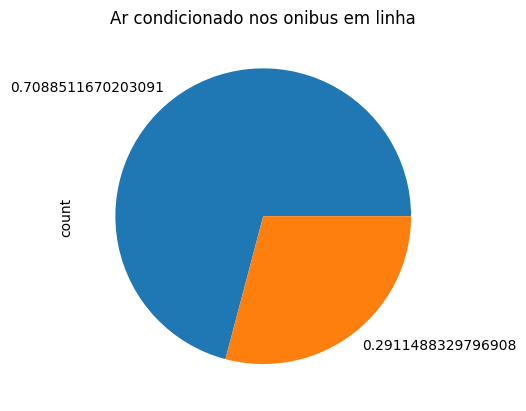

In [10]:
valores = veiculos_em_linha["indicador_ar_condicionado"].value_counts()
mapping = {True: valores[True]/(valores[False]+valores[True]), False: valores[False]/(valores[False]+valores[True])}
#Mexer nesses floats depois
veiculos_em_linha["indicador_ar_condicionado"].map(mapping).value_counts().plot(kind="pie",title="Ar condicionado nos onibus em linha")

Testes de corretude

In [11]:
print(veiculos_em_linha["id_veiculo"].nunique() == veiculos_em_linha.shape[0])
veic_linha_set = set(veiculos_em_linha["id_veiculo"].unique())
veic_set = set(veiculos["id_veiculo"].unique())
print(veic_linha_set - veic_set)
print(veic_set - veic_linha_set)

True
set()
set()
